In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
import numpy as np

In [2]:
VARIABLE = "temp" # "edv", "temp", or "heat_index"

assert VARIABLE in ["edv", "temp", "heat_index"], f"invalid `VARIABLE` value: {VARIABLE}"

INPUT_FILE = f"../data/{VARIABLE}/regional_{VARIABLE}_data.csv"
OUTPUT_FILE = f"../data/{VARIABLE}/{VARIABLE}_seasonality.csv"
PLOT_OUTPUT_FILE = f"../plots/seasonality/{VARIABLE}_seasonality.png"
USE_LN = True

In [3]:
OMEGA = 1/365.25
PHI = 2*np.pi*OMEGA

def f(t, beta_0, beta_s, beta_c):
    if USE_LN:
        return np.exp(beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t))
    else:
        return beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t)

In [4]:
df = pd.read_csv(INPUT_FILE, index_col=0)
y_min = df.values.min()
y_max = df.values.max()
y_range = y_max - y_min
df.head()

,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6,Region 7,Region 8,Region 9,Region 10
2018-01-01,-15.837069,-10.347318,-7.526191,0.256565,-15.160282,-0.363642,-13.126441,-9.710529,15.798783,-6.738495
2018-01-02,-12.189956,-5.388370,-5.612809,1.883143,-10.613858,1.298075,-4.330759,-1.674502,14.343217,-4.513651
2018-01-03,-5.170511,-3.484295,-2.236547,4.067688,-9.743023,9.192431,-1.263505,-1.196697,14.299780,-4.316342
2018-01-04,-4.535368,-5.003550,-4.980320,2.645091,-12.728201,10.064703,-1.880859,-0.142819,15.886730,-5.315687
2018-01-05,-6.707461,-11.330217,-9.039630,4.140429,-13.790228,13.971358,-2.651693,0.232164,16.154701,-5.215090


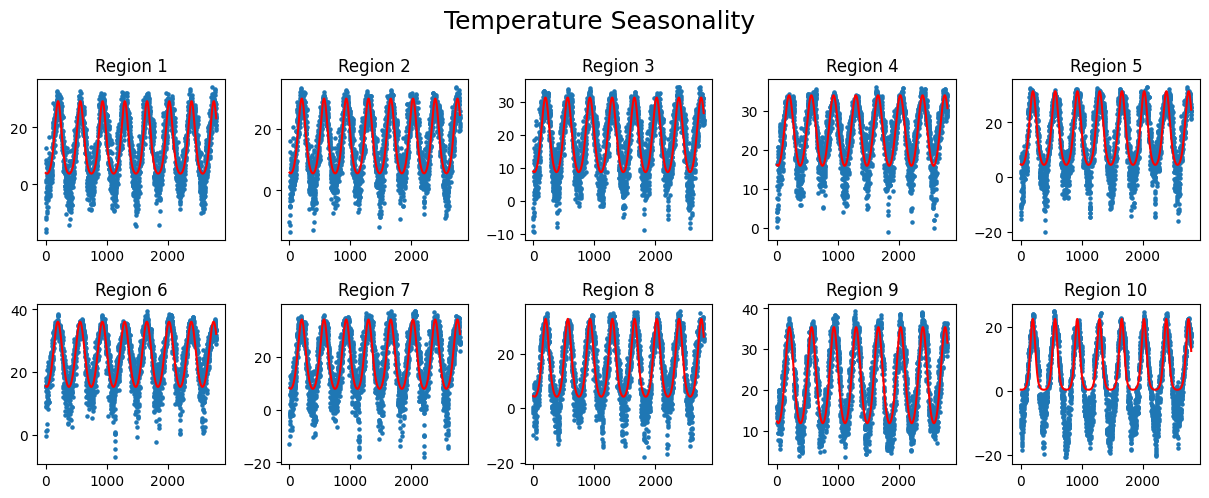

,region,beta_0,beta_s,beta_c,sigma_00,sigma_0s,sigma_0c,sigma_ss,sigma_sc,sigma_cc,psi,var_psi,peak_T,sigma_peak_T,peak_T_CI_lower,peak_T_CI_upper,gamma,var_gamma,theta
0,Region 1,2.349700,-0.344959,-0.966586,0.000149,0.000049,0.000153,0.000114,3.440243e-05,0.000214,0.342794,0.000098,202.552067,0.575103,201.424886,203.679247,1.026297,0.000180,2.790713
1,Region 2,2.556363,-0.273617,-0.798949,0.000081,0.000024,0.000080,0.000077,1.461698e-05,0.000124,0.329952,0.000102,201.805554,0.586207,200.656609,202.954499,0.844504,0.000110,2.326822
2,Region 3,2.805576,-0.187358,-0.611740,0.000040,0.000009,0.000036,0.000049,4.234575e-06,0.000067,0.297200,0.000117,199.901654,0.628620,198.669581,201.133727,0.639788,0.000063,1.896079
3,Region 4,3.146060,-0.102514,-0.365513,0.000010,0.000001,0.000007,0.000016,1.985446e-07,0.000018,0.273441,0.000113,198.520480,0.618892,197.307475,199.733485,0.379617,0.000018,1.461724
4,Region 5,2.469408,-0.291864,-0.931200,0.000131,0.000037,0.000135,0.000104,2.559915e-05,0.000194,0.303730,0.000102,200.281214,0.588029,199.128699,201.433729,0.975868,0.000171,2.653470
5,Region 6,3.154684,-0.119236,-0.414225,0.000012,0.000002,0.000009,0.000019,4.463689e-07,0.000022,0.280277,0.000103,198.917878,0.590051,197.761400,200.074356,0.431045,0.000022,1.538865
6,Region 7,2.794836,-0.229431,-0.697000,0.000065,0.000017,0.000062,0.000071,9.362383e-06,0.000104,0.317999,0.000127,201.110689,0.655362,199.826203,202.395175,0.733790,0.000095,2.082961
7,Region 8,2.459576,-0.356188,-0.963681,0.000128,0.000043,0.000131,0.000098,3.060373e-05,0.000183,0.354038,0.000084,203.205727,0.532954,202.161156,204.250299,1.027400,0.000153,2.793792
8,Region 9,3.019720,-0.196514,-0.510401,0.000013,0.000003,0.000010,0.000018,1.305899e-06,0.000022,0.367526,0.000058,203.989751,0.443510,203.120488,204.859014,0.546925,0.000021,1.727931
9,Region 10,1.013472,-0.533191,-2.026816,0.003304,0.000869,0.003519,0.000872,8.037583e-04,0.003951,0.257240,0.000154,197.578696,0.721289,196.164995,198.992397,2.095776,0.003356,8.131750


In [5]:
fig, axs = plt.subplots(2, 5, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.4)
data = []
for i, region in enumerate(df.columns):
    x = np.arange(len(df.index))
    y = df[region]
    betas, covs = curve_fit(f, x, y)

    beta_0, beta_s, beta_c = betas
    (sigma_00, sigma_0s, sigma_0c),\
    (_,        sigma_ss, sigma_sc),\
    (_,        _,        sigma_cc) = covs

    psi = np.arctan(beta_s/beta_c)
    var_psi = ((beta_c**2 * sigma_ss) + (beta_s**2 * sigma_cc) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)**2
    if beta_s > 0 and beta_c > 0:
        peak_T = psi / PHI
    elif beta_c < 0:
        peak_T = (psi + np.pi) / PHI
    else:
        peak_T = (psi + 2*np.pi) / PHI
    sigma_peak_T = np.sqrt(var_psi) / PHI
    z = norm.ppf(0.975)
    peak_T_CI = (peak_T - z*sigma_peak_T, peak_T + z*sigma_peak_T)
    gamma = np.sqrt(beta_c**2 + beta_s**2)
    var_gamma = ((beta_c**2 * sigma_cc) + (beta_s**2 * sigma_ss) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)
    theta = np.exp(gamma)
    M = z # M not specified in paper
    theta_CI = (np.exp(gamma - M*np.sqrt(var_gamma)), np.exp(gamma + M*np.sqrt(var_gamma)))

    data.append({
        "region": region,
        "beta_0": beta_0, "beta_s": beta_s, "beta_c": beta_c,
        "sigma_00": sigma_00, "sigma_0s": sigma_0s, "sigma_0c": sigma_0c, "sigma_ss": sigma_ss, "sigma_sc": sigma_sc, "sigma_cc": sigma_cc,
        "psi": psi, "var_psi": var_psi,
        "peak_T": peak_T, "sigma_peak_T": sigma_peak_T, "peak_T_CI_lower": peak_T_CI[0], "peak_T_CI_upper": peak_T_CI[1],
        "gamma": gamma, "var_gamma": var_gamma, "theta": theta,
        # "theta_CI_lower": theta_CI[0], "theta_CI_upper": theta_CI[1]
    })

    ax = axs[i//5,i%5]
    ax.scatter(x, y, s = 5)
    ax.plot(x, f(x, *betas), color = "red")
    ax.set_title(region)
    # ax.set_ylim(y_min - y_range*0.1, y_max + y_range*0.1)

if VARIABLE == "edv":
    suptitle = "EDV"
elif VARIABLE == "temp":
    suptitle = "Temperature"
elif VARIABLE == "heat_index":
    suptitle = "Heat Index"
plt.suptitle(f"{suptitle} Seasonality", fontsize = 18, y = 1.02)

plt.savefig(PLOT_OUTPUT_FILE, dpi = 500, bbox_inches = "tight")
plt.show()
df_models = pd.DataFrame(data)
df_models

In [6]:
df_models.to_csv(OUTPUT_FILE, index = False)